# DSAC B747 evaluation

Notebook to load trained DSAC agents, run single-episode evaluations, and plot the transient (step/sine) response of the Boeing 747 longitudinal environment.


In [ ]:
from __future__ import annotations

import numpy as np
import torch

from tensoraerospace.agent import DSAC
from tensoraerospace.envs.b747 import ImprovedB747Env
from tensoraerospace.signals.standard import unit_step

In [6]:
def pick_device() -> str:
    if torch.cuda.is_available():
        return "cuda"
    if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
        return "mps"
    return "cpu"


In [33]:
dt = 0.1
tn = 20.0
step_deg = 1.0
step_time_sec = 5.0
t = np.arange(0.0, tn + dt, dt, dtype=np.float32)
ref = unit_step(t, degree=step_deg, time_step=step_time_sec, output_rad=True).reshape(1, -1)
env = ImprovedB747Env(
    initial_state=np.array([0.0, 0.0, 0.0, 0.0], dtype=float),
    reference_signal=ref,
    number_time_steps=ref.shape[1],
    dt=dt,
    include_reference_in_obs=True,
    reward_mode="step_response",
)

In [ ]:
agent = DSAC.from_pretrained("TensorAeroSpace/dsac-b747-step-response")
agent.env = env
agent.to_device(pick_device())
agent.eval()


In [35]:
obs, _info = env.reset()
done = False
total = 0.0
log_time: list[float] = []
log_theta: list[float] = []
step_idx = 0
while not done:
    action = agent.select_action(obs, evaluate=True)
    obs, reward, terminated, truncated, info = env.step(action)
    done = bool(terminated or truncated)
    total += float(reward)

    current_time = step_idx * float(dt)
    theta_val = float(info.get("theta_rad", 0.0))
    log_time.append(current_time)
    log_theta.append(theta_val)
    step_idx += 1

result = {
    "time_s": np.asarray(log_time, dtype=float),
    "theta_deg": np.rad2deg(np.asarray(log_theta, dtype=float)),
}


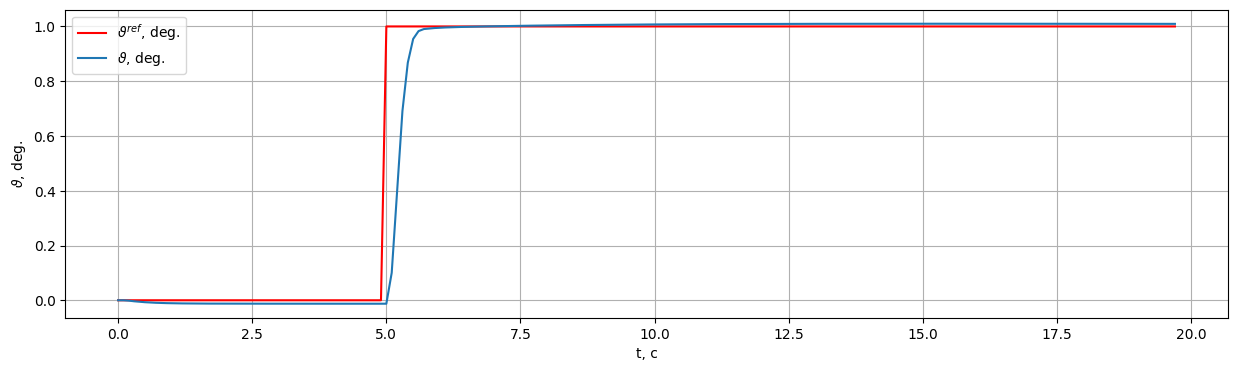

In [36]:
env.unwrapped.model.plot_transient_process(
    'theta',
    t,
    ref[0],
    to_deg=True,
    figsize=(15, 4)
)

/Users/asmazaev/TensorAeroSpace-Origin/tensoraerospace/aerospacemodel/base.py:388: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



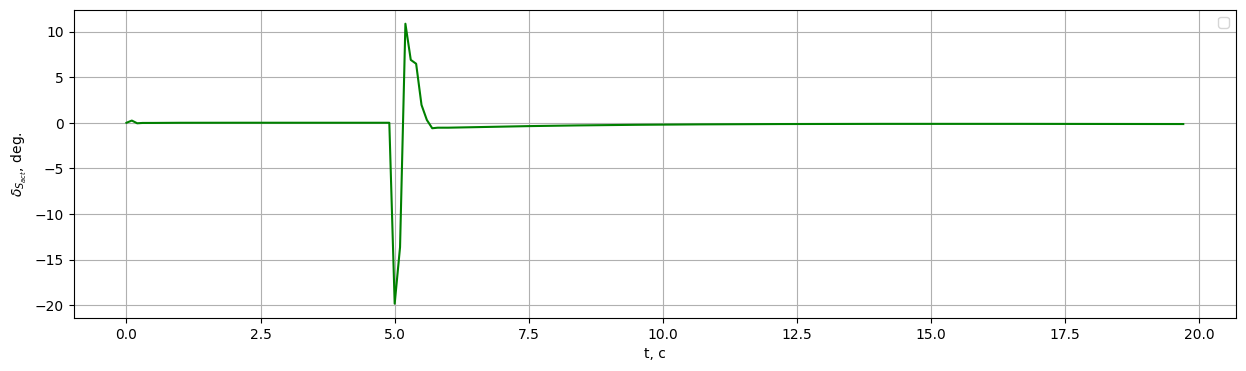

In [37]:
env.unwrapped.model.plot_control(control_name='ele', time=t, to_deg=True, figsize=(15,4))

In [48]:
value_sort_max = 1 * 0.05 + 1
value_sort_min = 1 - 1 * 0.05

theta_deg = result["theta_deg"]
# Find indices of values between min and max
between_mask = (theta_deg >= value_sort_min) & (theta_deg <= value_sort_max)
# Find the first contiguous run of such indices
indices = np.where(between_mask)[0]

# Split indices into contiguous runs
if indices.size > 0:
    # Find gaps where adjacent diffs are > 1
    splits = np.where(np.diff(indices) > 1)[0]
    start = 0
    if splits.size > 0:
        end = splits[0] + 1
    else:
        end = len(indices)
    first_sequence = indices[start:end]
    print("First run between min and max:", first_sequence)
    print("theta_deg values:", theta_deg[first_sequence])
else:
    print("No values between min and max")

Первая последовательность между min и max: [ 54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198]
Значения theta_deg: [0.95443152 0.98294635 0.99046674 0.99247983 0.9941383  0.99532481
 0.99623205 0.99696326 0.99758238 0.99812444 0.99860919 0.99905293
 0.99946764 0.99986049 1.00023581 1.00059631 1.00094367 1.00127903
 1.00160318 1.0019167  1.00222005 1.00251361 1.00279773 1.0030727
 1.00333881 1.00359633 1.00384551 1.00408661 1.00431985 1.00454547
 1.00476367 1

In [49]:
from tensoraerospace.benchmark.bench import ControlBenchmark

benchmark = ControlBenchmark()

# Prepare signals for benchmarking (rad)
t_arr = np.asarray(result["time_s"], dtype=float)
dt_local = float(t_arr[1] - t_arr[0]) if len(t_arr) > 1 else float(dt)
control_signal = ref[0, : len(t_arr)]
system_signal = np.deg2rad(np.asarray(result["theta_deg"], dtype=float))

baseline_val = float(control_signal[0]) if control_signal.size else 0.0

benchmark.plot(
    control_signal,
    system_signal,
    tps=t,
    signal_val=baseline_val,
    dt=dt_local,
    title="DSAC B747: Benchmark step response",
)

report = benchmark.generate_report(
    control_signal,
    system_signal,
    signal_val=baseline_val,
    dt=dt_local,
    system_name="DSAC B747",
)
print(report)




╔══════════════════════════════════════════════════════════════╗
║                    ОТЧЕТ О КАЧЕСТВЕ УПРАВЛЕНИЯ               ║
╠══════════════════════════════════════════════════════════════╣
║ Система: DSAC B747                                       ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║ 📊 ОСНОВНЫЕ ПОКАЗАТЕЛИ КАЧЕСТВА:                            ║
║                                                              ║
║ • Перерегулирование:         0.99%                    ║
║ • Время установления:       0.400 с                   ║
║ • Время нарастания:         0.400 с                   ║
║ • Время пика:              10.500 с                   ║
║ • Степень затухания:        0.000                      ║
║ • Статическая ошибка:     -0.0002                      ║
║ • Макс. отклонение:         0.016                      ║
║ • Количество колебаний:         0                        ║
║              